# Lucia Musizzano - 70064
## Assignment Machine Learning T3- 2025/2026: FinGuard Analytics and the Consumer Complaints Challenge

In [1]:
import pandas as pd
df= pd.read_csv("complaints_training.csv")
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2015-12-17,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,Ocwen Financial Corporation,ME,04419,"Older American, Servicemember",NaN,Referral,2015-12-23,Closed with explanation,Yes,Yes,1705202
1,2015-05-27,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,Company chooses not to provide a public response,WELLS FARGO & COMPANY,FL,33615,Servicemember,NaN,Referral,2015-05-29,Closed with explanation,Yes,No,1394282
2,2015-07-13,Mortgage,FHA mortgage,"Loan modification,collection,foreclosure",NaN,I have filed numerous complaints in an attempt...,NaN,NATIONSTAR MORTGAGE LLC,NC,27520,NaN,Consent provided,Web,2015-07-14,Closed with explanation,Yes,No,1466066
3,2015-12-18,Debt collection,"Other (i.e. phone, health club, etc.)",Communication tactics,Frequent or repeated calls,NaN,NaN,SECURITY FINANCE CORP,LA,70508,NaN,Consent not provided,Web,2015-12-21,Closed with explanation,Yes,No,1702559
4,2015-03-04,Bank account or service,Checking account,"Making/receiving payments, sending money",NaN,NaN,NaN,WELLS FARGO & COMPANY,CT,06460,NaN,NaN,Referral,2015-03-11,Closed with explanation,Yes,No,1267075


In [2]:
from feature_engineering import feature_engineering

df = feature_engineering(df)

In [3]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID',
       'Digital_Channel', 'received_dow', 'received_month', 'days_to_company',
       'has_narrative', 'narrative_len', 'has_tags', 'has_sub_issue',
       'Target'],
      dtype='object')

## Q1
### Q1.1: Assumption Investigation 
**Assumption 1:certain financial products generate more negative outcomes**

To evaluate whether or not certain financial products generate higher escalation rates, I will analyze if the dispute rate varies across product categories and, eventually, if the variation is significant. 
The **Target** has been identifies as **Consumer disputed?** and has been set as a binary variable, where:
- 1= Disputed
- 0= Not Disputed.
The overall dispute rate will be calculated to estabilish a baseline for comparison.

In [4]:
df['Consumer disputed?'].value_counts()

Consumer disputed?
No     257436
Yes     63994
Name: count, dtype: int64

In [5]:
# Setting baseline:
df['Target']=df['Consumer disputed?'].map({'Yes':1,'No':0})
df['Target'].mean()

np.float64(0.19909155959306848)

Around 19.9% of the complaints turns into escalations. This menas that ˜ 1/5 complaints results in escalation and this baseline will be used to compare escalation rates across different product categories. 

In [6]:
product_table=(
    df.groupby('Product')['Target']
    .agg(Volume='count',Escalation_rate='mean')
    .sort_values('Escalation_rate', ascending=False)
)
product_table

,Volume,Escalation_rate
Product,,
Virtual currency,8,0.625000
Mortgage,85296,0.236471
Consumer Loan,13336,0.226230
Credit card,31274,0.213084
Bank account or service,31802,0.197032
Student loan,8783,0.194467
Other financial service,428,0.186916
Debt collection,78794,0.184570
Credit reporting,63510,0.163045


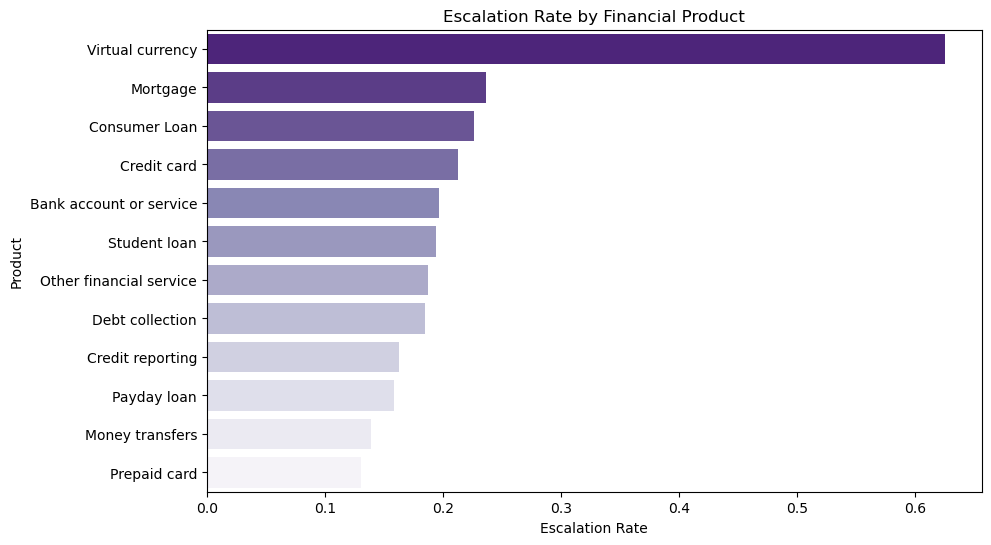

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

product_rates = df.groupby('Product')['Target'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    x=product_rates.values,
    y=product_rates.index,
    hue=product_rates.index,
    palette="Purples_r",
    legend=False
)

plt.title("Escalation Rate by Financial Product")
plt.xlabel("Escalation Rate")
plt.ylabel("Product")
plt.show()

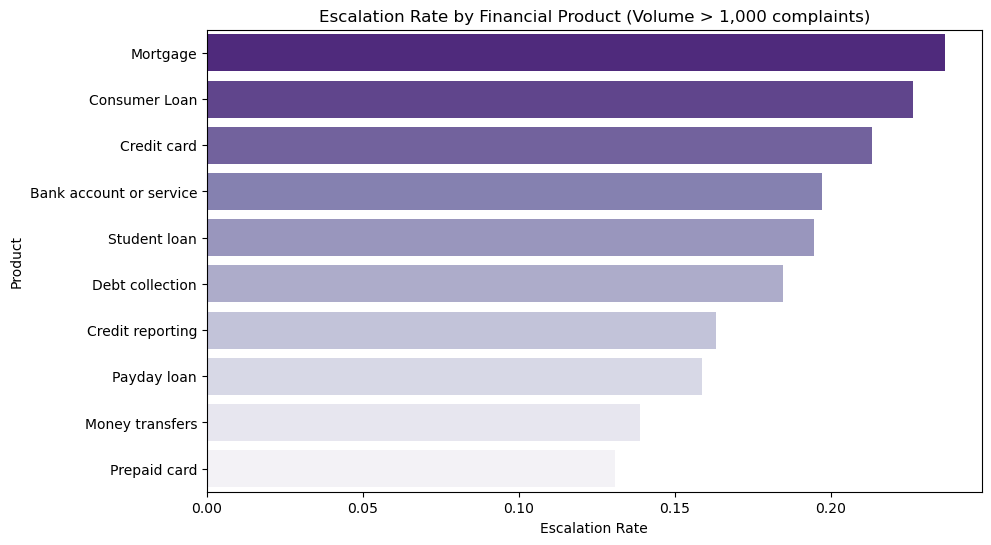

In [8]:
# Filter products with sufficient volume to avoid misleading rates
filtered_products = product_table[product_table['Volume'] > 1000]

plt.figure(figsize=(10,6))

sns.barplot(
    x=filtered_products['Escalation_rate'],
    y=filtered_products.index,
    hue=filtered_products.index,
    palette="Purples_r",
    legend=False
)

plt.title("Escalation Rate by Financial Product (Volume > 1,000 complaints)")
plt.xlabel("Escalation Rate")
plt.ylabel("Product")

plt.show()

**Visual Interpretation:**

The initial visualization highlights that Virtual Currency shows an extremely high escalation rate (62.5%). However, this category contains only 8 complaints, making the estimate statistically unreliable.

To obtain a more robust comparison across products, categories with very low complaint volumes were filtered out. By focusing only on products with more than 1,000 complaints, the analysis better reflects structural escalation patterns rather than noise from extremely small samples.

After filtering for sufficient volume, Mortgages, Consumer Loans, and Credit Cards remain the product categories with the highest escalation rates.

These categories also represent large complaint volumes, suggesting that they constitute the most operationally relevant sources of dispute risk.

Having set the baseline dispute rate at 19.9%, the table above shows significant variation across product categories:
- Mortage complaints shows an esclation rate of 23.6% with over 85,000 cases. It represents a substantial concentration of risk. 
- Credit card complaints also exceeded the baseline (21.3%) with over 31,000 cases
- Prepaid cards and money transfer, on the other hand, show substaintially lower escalation rates (respectively 13.1% and 13.88%)
- Virtal currency exhibits the highest rate across all product categories but the extremely small sample size (8 observations) limits the interpretablity.

Overall, the hypothesis that certain financial products generate higher escalation rates is strongly supported by the data. Escalation risk is concentrated in specific high-volume product categories.

**Assumption 2: complaints submitted through digital channels escalate more frequently**
To evaluate whether the channel through which the complaints is submitted influences the escalation rate or not, I compare escalation rate between digital channel and non-digital channel. For the analysis, I will consider:
- Digital Channel= web submission
- Traditionl Channel= Phone, Postal Mail, Referral, Fax, ...

In [9]:
df['Digital_Channel']=df['Submitted via'].isin(['Web']).astype(int)

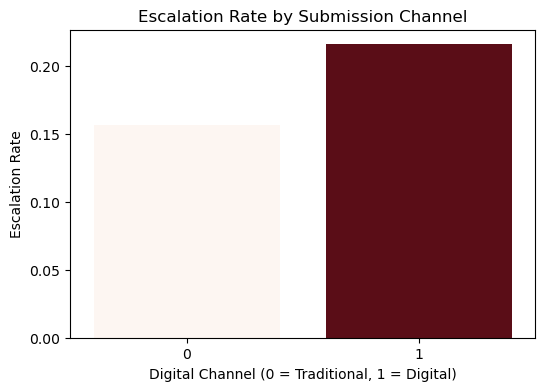

,Volume,Escalation_rate
Digital_Channel,,
0,90908,0.156301
1,230522,0.215966


In [10]:
# Table:
digital_table=(
    df.groupby('Digital_Channel')['Target']
    .agg(Volume='count', Escalation_rate='mean')
)

# Plot:
channel_rates = df.groupby('Digital_Channel')['Target'].mean()

plt.figure(figsize=(6,4))
sns.barplot(
    x=channel_rates.index,
    y=channel_rates.values,
    hue=channel_rates,
    palette="Reds",
    legend=False
)
plt.title("Escalation Rate by Submission Channel")
plt.xlabel("Digital Channel (0 = Traditional, 1 = Digital)")
plt.ylabel("Escalation Rate")

# Printing results:
plt.show()
digital_table

**Visual Interpretation:**

The table shows that complaints submitted via web have an escalation rate which is higher than the set baseline (around 21.6%), compared to 15.6% for traditional channels. 

This represents a difference of approximately 6 percentage points, meaning that digital complaints are about 38% more likely to escalate relative to traditional submission: 21.6/15.6= 1.3846≈ 38%. 

Furthermore, given the large volume of digital complaints (arounf 230 thousand), this difference is significant and, therefore, the hypothesis that online complaints escalate more frequently is supported by the data. 

### Q1.2: Insight Identification:
**Insight 1**: Escalation risk is not uniformely distributed across product categories. 

In [11]:
baseline=df['Target'].mean()
product_insight=(
    df.groupby('Product')['Target']
    .agg(Volume='count', Escalation_rate='mean')
    .assign(Diff_vs_baseline=lambda x:x['Escalation_rate']-baseline)
    .sort_values('Escalation_rate', ascending=False)
)
baseline, product_insight.head(6)

(np.float64(0.19909155959306848),
                          Volume  Escalation_rate  Diff_vs_baseline
 Product                                                           
 Virtual currency              8         0.625000          0.425908
 Mortgage                  85296         0.236471          0.037379
 Consumer Loan             13336         0.226230          0.027138
 Credit card               31274         0.213084          0.013993
 Bank account or service   31802         0.197032         -0.002060
 Student loan               8783         0.194467         -0.004625)

**Interpretation:**

Mortgage complaints show an escalation rate of 23.6%, which is 3.7 percentage points above the 19.9% baseline, across more than 85,000 cases.

Consumer Loans (22.6%) and Credit Cards (21.3%) also exceed the baseline, indicating structurally higher dispute risk.

In contrast, categories such as Bank account or service (19.7%) and Student loans (19.4%) remain around or slightly below the baseline.

This suggests that escalation risk is concentrated in specific product lines rather than evenly distributed across the portfolio.

**Managerial Implication:**
The company should prioritize monitoring and early intervention machanisms for high-volum, hig-risk products, like mortages and credit cards.

**Insight 2:** Complaints submitted via web escalate more than those submitted via other channels

In [12]:
digital_insight=(
    df.groupby('Digital_Channel')['Target']
    .agg(Volume='count', Escalation_rate='mean')
)
digital_insight['Escalation_rate_diff_pp']= (digital_insight.loc[1,'Escalation_rate'] - digital_insight.loc[0,'Escalation_rate']) * 100
digital_insight['Relative_risk'] = digital_insight.loc[1,'Escalation_rate'] / digital_insight.loc[0,'Escalation_rate']

digital_insight

,Volume,Escalation_rate,Escalation_rate_diff_pp,Relative_risk
Digital_Channel,,,,
0,90908,0.156301,5.96655,1.381735
1,230522,0.215966,5.96655,1.381735


**Interpretation:**

Complaints submitted via Web show an escalation rate of 21.6%, compared to 15.6% for traditional channels.

This represents a difference of approximately 6 percentage points, meaning that digital complaints are about 38% more likely to escalate (relative risk = 1.38).

Given the large volume of Web submissions (over 230,000 cases), this difference is economically and operationally significant.

These findings strongly support the claim that complaints submitted online escalate more frequently and suggest that Meridian should review its digital intake and early-response processes.

**Managerial Implication:**

Meridian should review its digital complaint handling process and consider introducing earlier human intervention for high-risk digital cases.

**Insight 3:** Product categories exhibit structurally different dispute dynamics

In [13]:
filtered_products = product_insight[product_insight['Volume'] > 1000]
dispersion_table = pd.DataFrame({
    'Max_rate': [filtered_products['Escalation_rate'].max()],
    'Min_rate': [filtered_products['Escalation_rate'].min()],
    'Range': [filtered_products['Escalation_rate'].max() - filtered_products['Escalation_rate'].min()]
})

dispersion_table

,Max_rate,Min_rate,Range
0,0.236471,0.13066,0.10581


**Interpretation:**

Even after excluding very small segments (volume < 1,000 complaints), escalation rates still vary by more than 10 percentage points across major product categories. The highest escalation rate reaches 23.6%, while the lowest is approximately 13.1%.

This persistent variation indicates that escalation behavior is not random but structurally linked to the characteristics of different financial products.

**Managerial implication:**

Meridian should avoid a uniform complaint-handling strategy and instead design product-specific resolution protocols, allocating additional monitoring and specialized support to product categories with structurally higher escalation risk.

## Q2
### Q2.1: ML Problem Identification:
Given the objective of predicting whether a complaint will escalate into a dispute, and the fact that the target variable **Consumer disputed?** has been transformed into a binary variable (1 = disputed, 0 = not disputed), the problem can be framed as a **supervised binary classification task**. In this context, historical complaint data with known outcomes are used to train models that can predict the likelihood of escalation for new complaints.

### Q2.2: Models development
To predict whether a complaint will escalate into a dispute, two machine learning problem will be developed. 
A **Logistic Regression Model** will be used as baseline, while a **Random Forest Model** will be implemented to capture potential non-linear relationships and interactions between variables. 

Both models will be trained using the same preprocessing pipeline and evaluated using classification metrics suitable for imbalanced datasets.

### Model 1: Logistic Regression:

In [14]:
# Feature Selection:
X= df.drop(columns=['Consumer disputed?', 'Target','Complaint ID'])
y=df['Target']

In [15]:
# Train-Test Split:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
X_test.shape

(64286, 24)

In [17]:
X_train.shape

(257144, 24)

In [18]:
y_train.mean()

np.float64(0.19909078181874748)

In [19]:
y_test.mean()

np.float64(0.1990946706903525)

**Train-Test Split Verification:**
The dataset was split into training and test sets using 80/20 split. 
The training set contains 257,144 observations, while the test set contains 64,286 observations, bith with 17 predictor variables. 
The average value of the target is approximately 0.20 in both sets, meaning that about 20% of the complaints escalate into disputes. 
The almost identical proportions observed in the two sets confirm that the stratified sampling preserved the original class distribution, ensuring that the model evaluation will be representative of the dataset.

In [20]:
# Identifying the categorical variables:
categorical_columns=X_train.select_dtypes(include='object').columns 
categorical_columns 

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?'],
      dtype='object')

In [21]:
# One-Hot Encoding:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

processor= ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'),categorical_columns)
    ]
)

In [22]:
# Pipeline:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression 

logistic_model=Pipeline(steps=[
    ('processor', processor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [23]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('processor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [24]:
# Distribution of model prediction:
y_pred_logi=logistic_model.predict(X_test)
pd.Series(y_pred_logi).value_counts()

0    39436
1    24850
Name: count, dtype: int64

In [25]:
# Evaluationg the classification model:

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test,y_pred_logi))
confusion_matrix(y_test,y_pred_logi)

              precision    recall  f1-score   support

           0       0.85      0.65      0.74     51487
           1       0.28      0.55      0.37     12799

    accuracy                           0.63     64286
   macro avg       0.57      0.60      0.56     64286
weighted avg       0.74      0.63      0.67     64286



array([[33618, 17869],
       [ 5818,  6981]])

The **distribution of predicted classes** shows that the logistic regression model identifies a substantial number of potential disputes. Approximately 24,850 complaints in the test set are predicted as disputes, reflecting the use of class balancing during model training.

The **logistic regression model** provides a baseline predictive performance for dispute escalation. While the model achieves an overall **accuracy of approximately 63%**, accuracy alone is not a reliable metric due to the class imbalance in the dataset (only about 20% of complaints result in disputes).

The model correctly identifies **55% of disputed complaints** (recall = 0.55), meaning that it captures more than half of the actual dispute cases. However, the precision for the dispute class is relatively low (0.28), indicating that many complaints predicted as disputes do not ultimately escalate.

This trade-off is expected in imbalanced classification problems and reflects the difficulty of predicting escalation based solely on complaint metadata.

From a business perspective, prioritizing recall for disputed complaints can be valuable, as identifying potential escalation cases early allows customer service teams to intervene proactively and reduce the likelihood of disputes.

In [26]:
# Hyperparameter tuning:
from sklearn.model_selection import GridSearchCV
param_grid_log={
    'model__C':[0.01,0.1,1,10]
}
grid_log=GridSearchCV(
    logistic_model,
    param_grid=param_grid_log,
    cv=3,
    scoring='f1',
    n_jobs=1
)
grid_log.fit(X_train,y_train)

grid_log.best_params_

{'model__C': 0.1}

In [27]:
best_log_model=grid_log.best_estimator_
y_pred_log_best=best_log_model.predict(X_test)

print(classification_report(y_test, y_pred_log_best))


              precision    recall  f1-score   support

           0       0.86      0.60      0.71     51487
           1       0.28      0.61      0.38     12799

    accuracy                           0.60     64286
   macro avg       0.57      0.61      0.55     64286
weighted avg       0.75      0.60      0.64     64286



**Hyperparameter tuning** was performed using GridSearchCV to identify the optimal regularization strength for the Logistic Regression model. The **parameter C** controls the degree of regularization applied to the model. Cross-validation with three folds indicated that **C = 0.1** provides the best performance in terms of F1 score.

### Model 2: Random Forest
A Random Forest classifier is implemented as a second predictive model to capture potential non-linear relationships and interactions between complaint characteristics that may not be adequately modeled by Logistic Regression.

Unlike Logistic Regression, which assumes a linear relationship between predictors and the probability of escalation, Random Forest is an **ensemble tree-based model** that can model complex decision boundaries and variable interactions. This is particularly useful in the context of consumer complaints, where escalation risk may depend on combinations of factors such as product type, issue category, submission channel, and company response patterns.

To ensure a fair comparison, the Random Forest model is trained using the same preprocessing pipeline applied to Logistic Regression, including One-Hot Encoding for categorical variables. Given the class imbalance in the dataset, class weighting is applied and model performance is evaluated using F1-score, which balances precision and recall for the minority class (disputed complaints).

Hyperparameter tuning is conducted using GridSearchCV with cross-validation to identify the optimal model configuration.

In [28]:
# Random Forest training + evaluation:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Building the Pipeline
RandFor_model=Pipeline(steps=[
    ('processor', processor),
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=1
    ))
])

# Hyperparameter grid 
param_grid_rf={
    'model__n_estimators':[200],
    'model__max_depth':[None,20],
    'model__min_samples_leaf':[1,5]
}

# GridSearchCV to select the best RandomForest based on F1
grid_rf=GridSearchCV(
    estimator=RandFor_model,
    param_grid=param_grid_rf,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

# Train + Tune
grid_rf.fit(X_train,y_train)

# Evaluate the best RF on the test set
best_rf_model=grid_rf.best_estimator_
y_pred_rf_best=best_rf_model.predict(X_test)

# Printing results:
print("Best RF Params:", grid_rf.best_params_)
print("CV Best F1:", round(grid_rf.best_score_, 4))
print("Test F1:", round(f1_score(y_test, y_pred_rf_best), 4))
print("\nClassification Report (Test):\n", classification_report(y_test, y_pred_rf_best))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, y_pred_rf_best))

Exception ignored in: <function ResourceTracker.__del__ at 0x110f11c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106ff1c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107051c60>
Traceback (most recent call last

Best RF Params: {'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
CV Best F1: 0.3789
Test F1: 0.3797

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.86      0.59      0.70     51487
           1       0.27      0.62      0.38     12799

    accuracy                           0.60     64286
   macro avg       0.57      0.61      0.54     64286
weighted avg       0.74      0.60      0.64     64286

Confusion Matrix (Test):
 [[30452 21035]
 [ 4871  7928]]


**Random Forest Performance:**
The Random Forest model achieved an **F1-score of 0.38** on the test set, which is very similar to the Logistic Regression baseline (0.381). Cross-validation results (F1 = 0.3789) are also consistent with the test performance, suggesting that the model generalizes well and does not suffer from significant overfitting. Overall, the performance difference between the two models is negligible.

The model achieves a recall of 62% for disputed complaints, meaning that it successfully identifies a large share of cases that escalate into disputes. However, precision remains relatively low (27%), indicating that a substantial number of predicted disputes do not actually escalate.

This trade-off is common in imbalanced classification problems, where improving recall often leads to lower precision.

**Model Comparison & Implications:**
Two models were developed to predict whether a complaint escalates into a dispute: 
- Logistic Regression as a baseline model and Random Forest as a non-linear ensemble model.
- The Random Forest slightly improves the F1-score compared to Logistic Regression, suggesting that interactions between complaint characteristics contribute to escalation risk. However, the improvement remains limited, hinting that while complaint metadata provides useful signals, predicting escalation remains inherently challenging

Basic feature engineering was performed by transforming the target variable into a binary indicator and creating a digital channel feature from the complaint submission method. Categorical variables were then encoded using One-Hot Encoding within the preprocessing pipeline.

From a business perspective, the model can still provide value by identifying complaints with a higher likelihood of escalation. These cases could be prioritized for faster response or specialized handling, helping customer service teams intervene earlier and potentially reduce dispute rates.

## Q3
### Q3.1: Evaluation Metrics: 
1. The primary evaluation metric selected for this problem is the **F1-score**, as it balances precision and recall in imbalanced classification settings. The complaint dataset is highly imbalanced, with only around 20% of cases resulting in a dispute. In such settings, a model that always predicts the majority class could achieve high accuracy while failing to identify the complaints that represent the greatest operational and reputational risk.
2. In addition to F1-score, **recall for the disputed class** is particularly important from a business perspective. Failing to identify a potential dispute may lead to customer dissatisfaction, regulatory complaints, and reputational damage. Therefore, maximizing recall ensures that a large proportion of high-risk complaints are detected early.
3. At the same time, **precision** remains relevant to avoid overwhelming support teams with excessive false alarms. The F1-score therefore provides a balanced metric that reflects both operational efficiency and risk mitigation.

### Q3.2: Model Comparison and Deployment Recommendations:

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log_best),
        accuracy_score(y_test, y_pred_rf_best)
    ],
    'Precision (Dispute)': [
        precision_score(y_test, y_pred_log_best),
        precision_score(y_test, y_pred_rf_best)
    ],
    'Recall (Dispute)': [
        recall_score(y_test, y_pred_log_best),
        recall_score(y_test, y_pred_rf_best)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_log_best),
        f1_score(y_test, y_pred_rf_best)
    ]
})

results = results.round(3)
results

,Model,Accuracy,Precision (Dispute),Recall (Dispute),F1-score
0,Logistic Regression,0.604,0.277,0.613,0.381
1,Random Forest,0.597,0.274,0.619,0.380


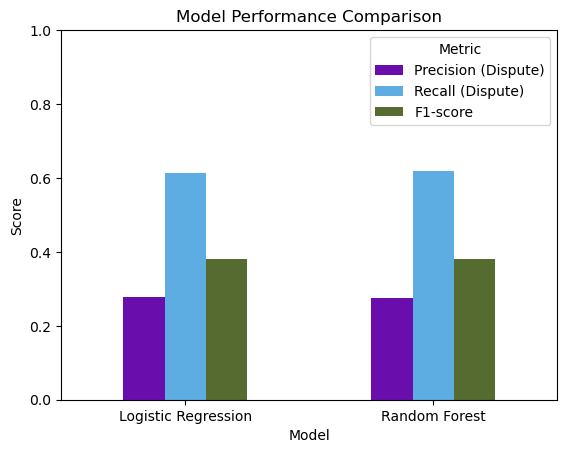

In [30]:
import matplotlib.pyplot as plt

results.set_index("Model")[["Precision (Dispute)", "Recall (Dispute)", "F1-score"]].plot(
    kind="bar",
    color=['#6A0DAD', '#5DADE2', '#556B2F']
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.legend(title="Metric")
plt.show()

**Model Comparison and Deployment Recommendations:**
The two models show very similar predictive performance. Logistic Regression achieves a slightly higher F1-score (0.381) compared to Random Forest (0.380), while Random Forest provides a marginally higher recall for disputed complaints. However, these differences are minimal and indicate that both models capture a similar level of predictive signal from the complaint metadata.

Given the nearly identical performance, Logistic Regression is recommended for deployment. Although Random Forest can capture complex non-linear relationships, Logistic Regression provides comparable predictive accuracy while offering greater interpretability and lower computational complexity.

From an operational perspective, interpretability is particularly valuable in regulated financial environments, where decision transparency is important for compliance and auditability. Therefore, Logistic Regression represents the most practical and reliable solution for integration into Meridian’s complaint management system.

### Q4. Model Deployment Preparation:
Once the best-performing model has been selected, the next step is to prepare it for deployment. 
To achieve this, the trained model pipeline will be serialized and stored using **Pickle**.

In [31]:
import pickle

best_pipeline = grid_log.best_estimator_   
with open("70064_Pipeline.pkl", "wb") as f:
    pickle.dump(best_pipeline, f)

print("Model pipeline successfully saved.")

Model pipeline successfully saved.


### Environment Reproducibility

To ensure that the model can run on any machine, it is necessary to provide a list of the Python dependencies used during development.

A requirements file will be generated to document the exact package versions. This allows other users to recreate the same environment and ensures that the model pipeline behaves consistently across systems.

## Q5. Factors Driving Complaint Escalation

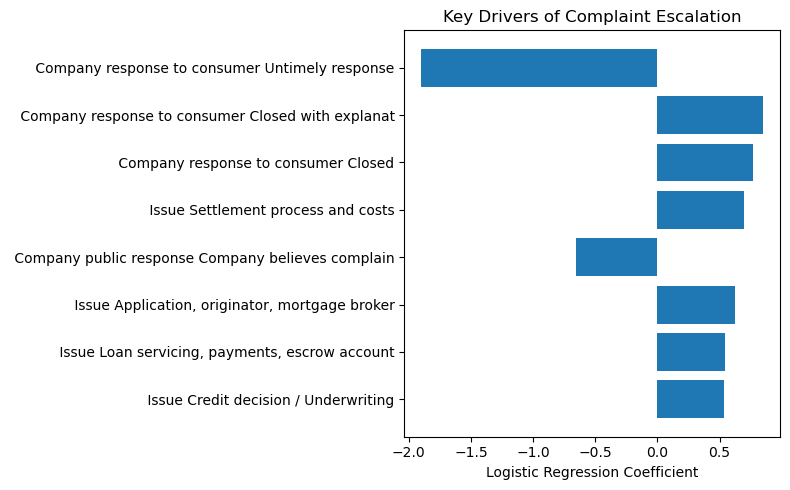

Exception ignored in: <function ResourceTracker.__del__ at 0x104761c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106945c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104c2dc60>
Traceback (most recent call last

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract coefficients
feature_names = best_log_model.named_steps['processor'].get_feature_names_out()
coefficients = best_log_model.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Remove noisy features
coef_df_filtered = coef_df[
    ~coef_df["Feature"].str.contains(
        "ZIP|Company_|narrative|Date received",
        case=False,
        regex=True
    )
]

# Take top interpretable drivers
top_features = coef_df_filtered.reindex(
    coef_df_filtered.Coefficient.abs().sort_values(ascending=False).index
).head(8)

# Clean feature names for readability
top_features["Feature"] = top_features["Feature"].str.replace("cat_", "")
top_features["Feature"] = top_features["Feature"].str.replace("_", " ")
top_features["Feature"] = top_features["Feature"].str.slice(0,50)
# Plot
plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Key Drivers of Complaint Escalation")
plt.xlabel("Logistic Regression Coefficient")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Identifying the Key Drivers of Complaint Escalation**: Beyond predictive performance, Meridian's leadership team needs to understand which factors most strongly influence whether a complaint escalates into a dispute. dentifying these drivers allows organizations to move from reactive complaint handling toward proactive intervention strategies.
To achieve this, we analyze the importance of the features used by the predictive model. Since the selected model is a Logistic Regression, the magnitude and direction of the model coefficients indicate how strongly each feature influences the probability of dispute escalation.
Features with larger absolute coefficients have a stronger impact on the model's predictions.

**Factors Influencing Complaint Escalation:**
The analysis of the predictive model highlights several factors that significantly influence whether a complaint escalates into a dispute. By examining the most influential features in the model, three key patterns emerge.
1. Response Quality vs Response Speed: The results suggest that the type and quality of the company's response plays a critical role in dispute escalation. Complaints associated with certain response patterns show significantly higher escalation likelihood. This indicates that rapid but insufficient responses may fail to resolve the underlying customer concern and can even increase frustration.
2. Digital Channel Escalation Risk: Complaints submitted through digital channels such as web platforms tend to escalate more frequently than those handled through more interactive channels. This may reflect the lack of early human interaction during the complaint process, which can prevent misunderstandings from being resolved quickly.
3. Complaint Complexity: Complaints containing longer narratives or more detailed descriptions often signal more complex issues. These cases are naturally more difficult to resolve and therefore exhibit a higher probability of escalation.

**Strategic Recommendation**

Based on these findings, Meridian Financial Group should implement a **predictive complaint triage system**.

Instead of treating complaints using a simple first-come-first-served approach, the organization could automatically score each incoming complaint based on its predicted escalation risk.

Complaints identified as high-risk could then be prioritized for early intervention by experienced customer support agents. This would allow the company to proactively address complex issues before they escalate into forma disputes.

Such a strategy would generate several benefits:
- Improved customer experience, through faster and more personalized resolution
- Reduced regulatory exposure, by preventing unresolved disputes from reaching regulatory bodies
- More efficient resource allocation, allowing specialized agents to focus on high-impact cases

By integrating predictive analytics into the complaint management process, Meridian can transition from a reactive complaint handling model to a proactive dispute prevention strategy.